### Week 11 - AI Mini Project

#### Task

Build a small AI system.

#### Project Chosen
**Customer Churn Prediction**

#### Objective
Develop a Machine Learning model that predicts whether a customer is likely to close a bank account based on customer data and behavioral patterns.

#### Deliverables

1. **Model**
   - Train and evaluate a Customer Churn Prediction model.

2. **Explanation**
   - Explain the problem statement, dataset, preprocessing, model selection, and results.

3. **GitHub Repository**
   - Upload the source code, model, dataset, and project documentation to GitHub.

### 1.importing Libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix

### 2.Load Dataset:

In [20]:
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 3.Dataset Summary

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [22]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 4.Checking for Missing Value:

In [23]:
print("Finding Missing Values: ")
print(df.isnull().sum())

Finding Missing Values: 
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


### Churn Distribution:

Churn distribution:
churn
0    7963
1    2037
Name: count, dtype: int64
churn
0    0.796
1    0.204
Name: proportion, dtype: float64


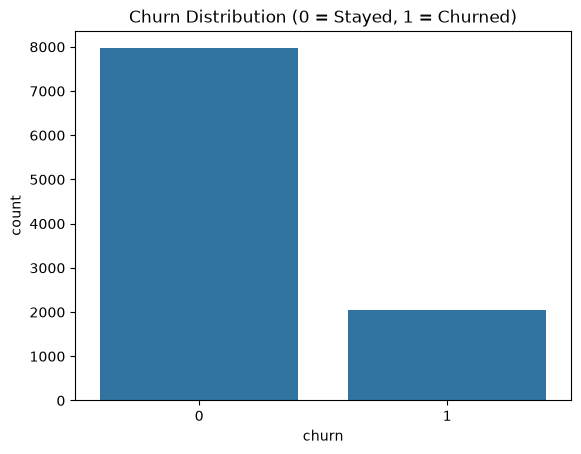

In [24]:
print("Churn distribution:")
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True).round(3))

sns.countplot(x="churn", data=df)
plt.title("Churn Distribution (0 = Stayed, 1 = Churned)")
plt.show()

### 5.Checking for Duplicate Values:

In [25]:
print('Duplicate Row: ',df.duplicated().sum())

Duplicate Row:  0


### 6.Identify The Correlation:

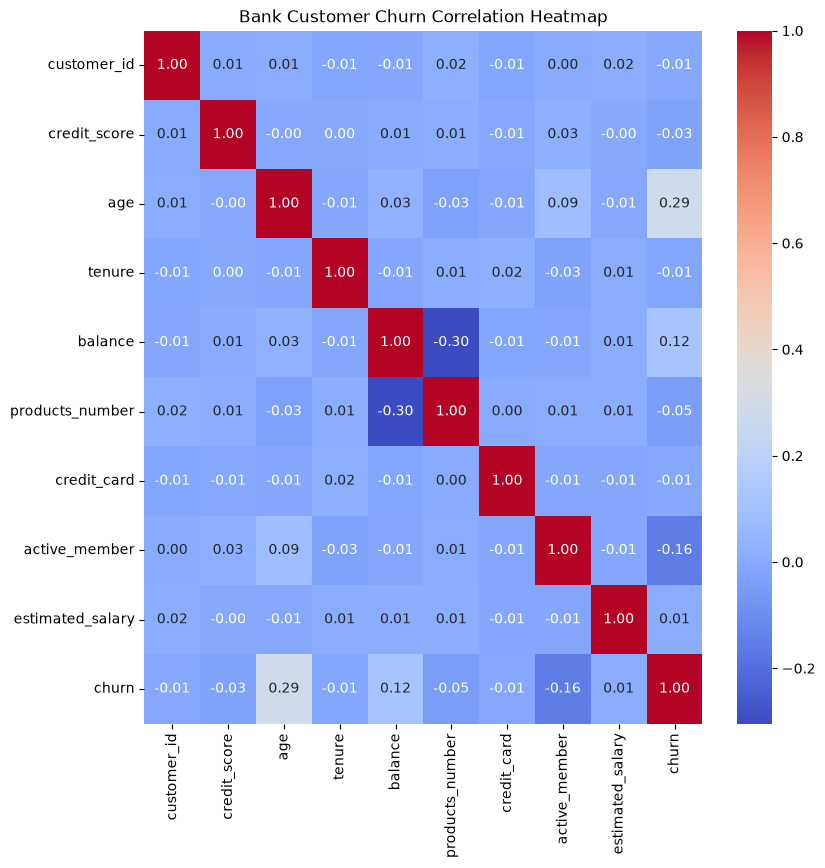

In [26]:
correlation = df.select_dtypes(include='number').corr()
plt.figure(figsize=(9,9))
sns.heatmap(
    correlation,
    annot=True,    #it will show the value inside the correlation map
    cmap='coolwarm',
    fmt='.2f'   #used for formatting values 
)
plt.title('Bank Customer Churn Correlation Heatmap')
plt.show()

#### **Key Insights from Correlation Analysis:**

1. **Age has the Strongest Positive Correlation (+0.29):**
   - Older customers exhibit a significantly higher likelihood of churning. Retention efforts and loyalty perks should specifically target middle-aged and senior banking clients.

2. **Active Membership is the Strongest Retention Factor (-0.16):**
   - There is a notable negative correlation between `active_member` and churn. Customers who actively transact and engage with bank services are substantially less likely to leave.

3. **Account Balance Positively Correlates with Churn (+0.12):**
   - Customers holding higher account balances show higher churn rates. This suggests that high-net-worth clients frequently seek higher-yield returns, better investment products, or competitive offers from other financial institutions.

4. **Weak Linear Correlation for Credit Score, Tenure, and Salary (-0.03 to +0.01):**
   - Metrics like credit score, length of tenure, credit card ownership, and estimated salary have near-zero direct linear correlation with churn. This indicates churn is driven by complex non-linear feature interactions, justifying the use of non-linear tree models like Random Forest.

### 7. Preprocessing: Encode Categorical Features & Split Data

In [ ]:
# customer_id is just an identifier, not a predictive feature
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

numeric_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number',
                     'credit_card', 'active_member', 'estimated_salary']
categorical_features = ['country', 'gender']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (8000, 10)  Test shape: (2000, 10)


### 8. Train and Compare Models

We compare a Logistic Regression baseline against a Random Forest classifier, since churn is a tabular classification problem and the two behave very differently on non-linear feature interactions and the class imbalance present in the data (~20% churn).

In [ ]:
log_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
log_pipe.fit(X_train, y_train)
log_pred = log_pipe.predict(X_test)
log_proba = log_pipe.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_proba))
print(classification_report(y_test, log_pred))

=== Logistic Regression ===
Accuracy: 0.714
ROC-AUC: 0.7771824212502177
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [29]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42
))
])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 0.8485
ROC-AUC: 0.8637836603938298
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1593
           1       0.63      0.63      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



### 9. Confusion Matrix (Best Model)

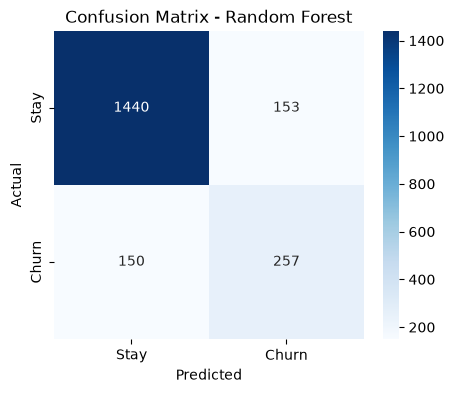

In [30]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### 10. Export the Trained Pipeline

The Random Forest pipeline (preprocessing + classifier bundled together) scored higher on accuracy and ROC-AUC, so it is the model we serialize with `joblib` for deployment. Saving the whole `Pipeline` — not just the classifier — means the API only needs to load one file and can pass in raw feature values exactly as they appear in the source data.

In [31]:
best_pipe = rf_pipe  # Random Forest outperformed Logistic Regression on ROC-AUC

os.makedirs("model", exist_ok=True)
joblib.dump(best_pipe, "model/churn_model.pkl")
print("Pipeline (preprocessing + RandomForestClassifier) saved to model/churn_model.pkl")

Pipeline (preprocessing + RandomForestClassifier) saved to model/churn_model.pkl
